<a href="https://colab.research.google.com/github/aishujadhav1321/sales-data-mini-project/blob/main/sales_data_mini_project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
print(df.columns.tolist())

['Order_ID', 'Product', 'Category', 'Quantity', 'Unit_Price', 'Region', 'Month', 'Total_Sales']


DATASET PREVIEW
   Order_ID     Product     Category  Quantity  Unit_Price Region Month  \
0      1001     Printer    Furniture         3        3693  North   Apr   
1      1002  Headphones  Electronics         3       30467   West   Apr   
2      1003       Chair  Electronics         1       30723  North   Mar   
3      1004     Printer  Electronics         3       47699   East   Apr   
4      1005      Tablet  Electronics         5        4627  North   Mar   

   Total_Sales  
0        11079  
1        91401  
2        30723  
3       143097  
4        23135  

DESCRIPTIVE STATISTICS
Mean Sales: 93745.26
Median Sales: 91085.00
Mode Sales: 1663.00
Variance: 6308413266.32
Standard Deviation: 79425.52

PROBABILITY ANALYSIS
Probability(Total Sales > 5000) = 0.9800
Percentage = 98.00%

95% CONFIDENCE INTERVAL
Lower Limit: 71172.78
Upper Limit: 116317.74

ONE SAMPLE T-TEST
T Statistic: 7.9008
P Value: 0.0
Result: Reject Null Hypothesis
Average sales significantly differ from ₹5000

CHI-SQU

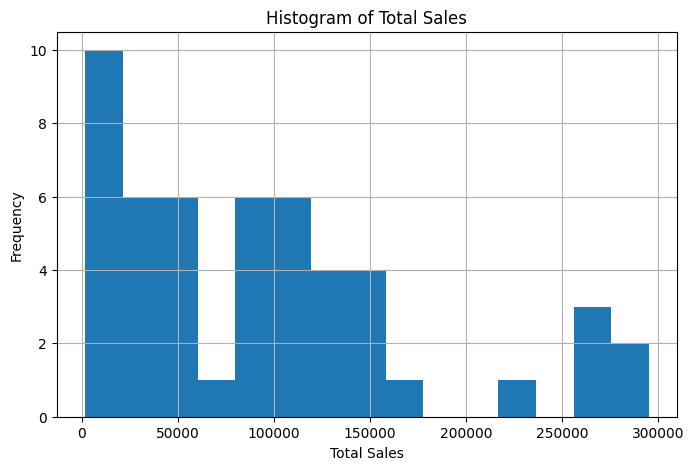

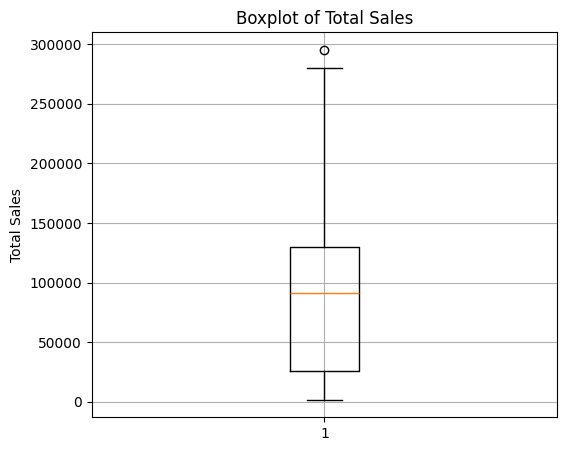

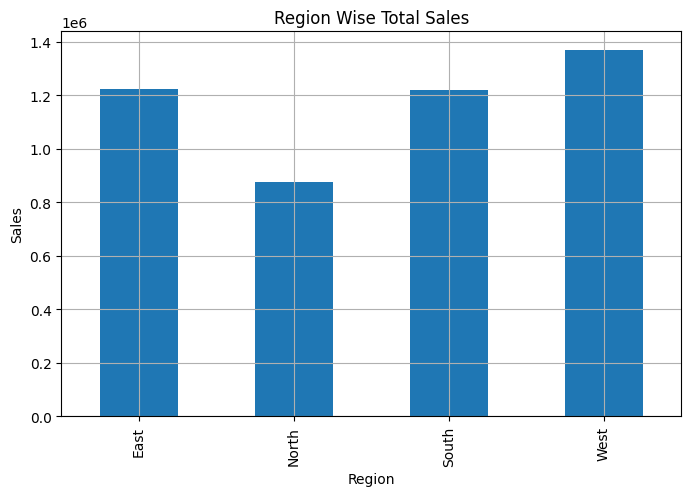

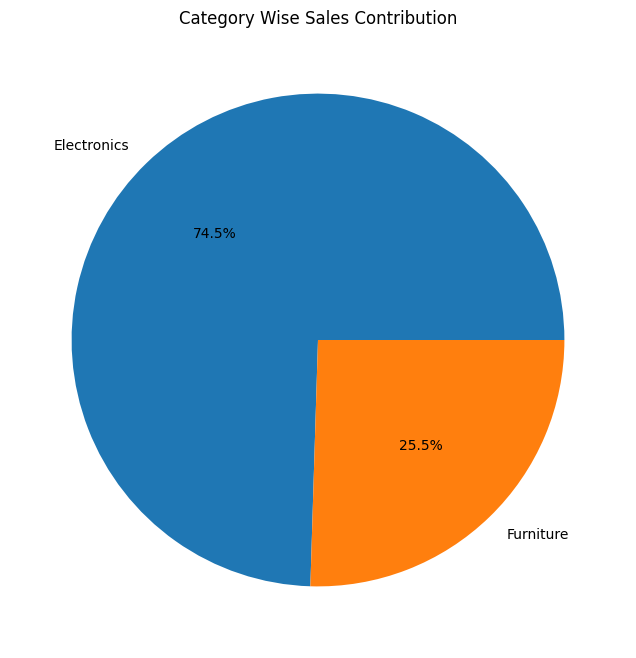

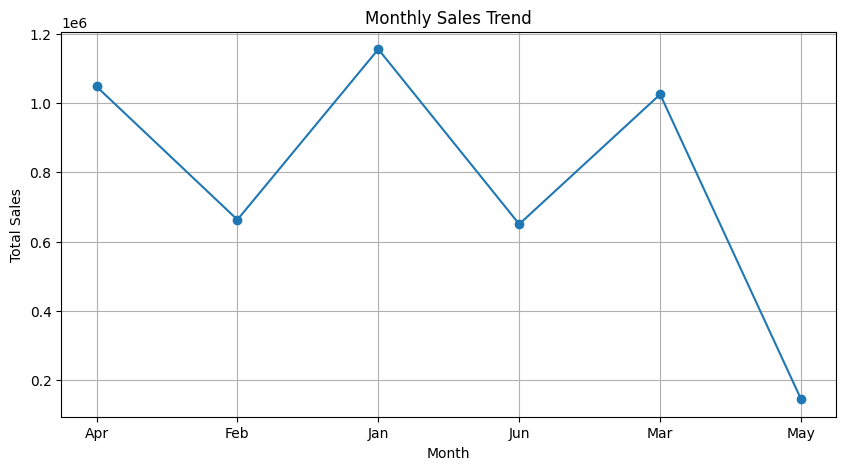


PROJECT SUMMARY
Average Sales: 93745.26
Median Sales: 91085.00
Standard Deviation: 79425.52
Probability of Sales > 5000: 98.00%
95% Confidence Interval: (71172.78, 116317.74)

Project Completed Successfully!


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ttest_1samp, chi2_contingency

# =====================================================
# LOAD DATASET
# =====================================================

df = pd.read_csv("sales_data.csv")

print("="*60)
print("DATASET PREVIEW")
print("="*60)
print(df.head())

# =====================================================
# DESCRIPTIVE STATISTICS
# =====================================================

print("\n" + "="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)

mean_sales = df['Total_Sales'].mean()
median_sales = df['Total_Sales'].median()
mode_sales = df['Total_Sales'].mode()[0]
variance_sales = df['Total_Sales'].var()
std_sales = df['Total_Sales'].std()

print(f"Mean Sales: {mean_sales:.2f}")
print(f"Median Sales: {median_sales:.2f}")
print(f"Mode Sales: {mode_sales:.2f}")
print(f"Variance: {variance_sales:.2f}")
print(f"Standard Deviation: {std_sales:.2f}")

# =====================================================
# PROBABILITY ANALYSIS
# =====================================================

print("\n" + "="*60)
print("PROBABILITY ANALYSIS")
print("="*60)

threshold = 5000

probability = len(df[df['Total_Sales'] > threshold]) / len(df)

print(f"Probability(Total Sales > {threshold}) = {probability:.4f}")
print(f"Percentage = {probability*100:.2f}%")

# =====================================================
# CONFIDENCE INTERVAL
# =====================================================

print("\n" + "="*60)
print("95% CONFIDENCE INTERVAL")
print("="*60)

sales = df['Total_Sales']

mean = np.mean(sales)
sem = stats.sem(sales)

confidence_interval = stats.t.interval(
    confidence=0.95,
    df=len(sales)-1,
    loc=mean,
    scale=sem
)

print("Lower Limit:", round(confidence_interval[0], 2))
print("Upper Limit:", round(confidence_interval[1], 2))

# =====================================================
# ONE SAMPLE T-TEST
# =====================================================

print("\n" + "="*60)
print("ONE SAMPLE T-TEST")
print("="*60)

target_sales = 5000

t_stat, p_value = ttest_1samp(
    df['Total_Sales'],
    target_sales
)

print("T Statistic:", round(t_stat, 4))
print("P Value:", round(p_value, 4))

if p_value < 0.05:
    print("Result: Reject Null Hypothesis")
    print("Average sales significantly differ from ₹5000")
else:
    print("Result: Fail to Reject Null Hypothesis")
    print("Average sales do not significantly differ from ₹5000")

# =====================================================
# CHI-SQUARE TEST
# =====================================================

print("\n" + "="*60)
print("CHI-SQUARE TEST")
print("="*60)

contingency_table = pd.crosstab(
    df['Region'],
    df['Category']
)

print("\nContingency Table:")
print(contingency_table)

chi2, p, dof, expected = chi2_contingency(
    contingency_table
)

print("\nChi-Square Statistic:", round(chi2, 4))
print("P-value:", round(p, 4))
print("Degrees of Freedom:", dof)

if p < 0.05:
    print("Result: Region and Category are associated")
else:
    print("Result: Region and Category are independent")

# =====================================================
# HISTOGRAM
# =====================================================

plt.figure(figsize=(8,5))
plt.hist(df['Total_Sales'], bins=15)
plt.title("Histogram of Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# =====================================================
# BOXPLOT
# =====================================================

plt.figure(figsize=(6,5))
plt.boxplot(df['Total_Sales'])
plt.title("Boxplot of Total Sales")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

# =====================================================
# REGION WISE SALES
# =====================================================

region_sales = df.groupby('Region')['Total_Sales'].sum()

plt.figure(figsize=(8,5))
region_sales.plot(kind='bar')
plt.title("Region Wise Total Sales")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

# =====================================================
# CATEGORY WISE SALES
# =====================================================

category_sales = df.groupby('Category')['Total_Sales'].sum()

plt.figure(figsize=(8,8))
category_sales.plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.ylabel('')
plt.title("Category Wise Sales Contribution")
plt.show()

# =====================================================
# MONTHLY SALES TREND
# =====================================================

monthly_sales = df.groupby('Month')['Total_Sales'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

# =====================================================
# SUMMARY
# =====================================================

print("\n" + "="*60)
print("PROJECT SUMMARY")
print("="*60)

print(f"Average Sales: {mean_sales:.2f}")
print(f"Median Sales: {median_sales:.2f}")
print(f"Standard Deviation: {std_sales:.2f}")
print(f"Probability of Sales > 5000: {probability:.2%}")
print(f"95% Confidence Interval: ({confidence_interval[0]:.2f}, {confidence_interval[1]:.2f})")

print("\nProject Completed Successfully!")